In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [41]:
df = pd.read_csv('Athelete.csv')

print(df.shape)
print(df.head())


(3111, 28)
              Athlete        Date Day.of.Week   RHR    HRV  Recovery  \
0  Athlete 1 Bergdorf  01-01-2022         NaN   NaN    NaN       NaN   
1  Athlete 1 Bergdorf  01-10-2022      Monday  48.0  120.0      58.0   
2  Athlete 1 Bergdorf  01-11-2022         NaN   NaN    NaN       NaN   
3  Athlete 1 Bergdorf  01-12-2022         NaN   NaN    NaN       NaN   
4  Athlete 1 Bergdorf   1/13/2022    Thursday  53.0  121.0      61.0   

   Sleep.Score  Hours.in.Bed  Hours.of.Sleep  Sleep.Need  ...  Awake..hours.  \
0          NaN           NaN             NaN         NaN  ...            NaN   
1         51.0          6.36            5.62       11.02  ...           0.74   
2          NaN           NaN             NaN         NaN  ...            NaN   
3          NaN           NaN             NaN         NaN  ...            NaN   
4         55.0          6.25            5.56       10.15  ...           0.70   

   Sleep.Debt..hours.  Sleep.Consistency  Respiratory.Rate  \
0            

In [42]:
print(df.describe())
print(df.info())


               RHR          HRV     Recovery  Sleep.Score  Hours.in.Bed  \
count  1981.000000  1981.000000  1981.000000  1981.000000   1981.000000   
mean     59.693084    84.065623    59.546189    76.393236      7.780843   
std       9.003574    36.105314    22.664673    18.553590      1.927197   
min      39.000000    14.000000     1.000000    10.000000      1.050000   
25%      53.000000    56.000000    43.000000    64.000000      6.580000   
50%      58.000000    79.000000    61.000000    78.000000      7.800000   
75%      65.000000   110.000000    77.000000    92.000000      8.960000   
max     120.000000   188.000000    99.000000   100.000000     17.130000   

       Hours.of.Sleep   Sleep.Need  Sleep.Efficiency....  Wake.Periods  \
count     1981.000000  1981.000000           1981.000000   1621.000000   
mean         6.890545     8.910611             88.865724     14.870450   
std          1.652425     1.117639              6.296796      6.613342   
min          0.820000     1.

In [43]:
for column in df.columns:
    print(f"Column '{column}': {df[column].isna().sum()} null values")

Column 'Athlete': 0 null values
Column 'Date': 0 null values
Column 'Day.of.Week': 1124 null values
Column 'RHR': 1130 null values
Column 'HRV': 1130 null values
Column 'Recovery': 1130 null values
Column 'Sleep.Score': 1130 null values
Column 'Hours.in.Bed': 1130 null values
Column 'Hours.of.Sleep': 1130 null values
Column 'Sleep.Need': 1130 null values
Column 'Sleep.Efficiency....': 1130 null values
Column 'Wake.Periods': 1490 null values
Column 'Sleep.Disturbances': 1130 null values
Column 'Latency..min.': 1130 null values
Column 'Cycles': 1130 null values
Column 'REM.Sleep..hours.': 1130 null values
Column 'Deep.Sleep..hours.': 1130 null values
Column 'Light.Sleep..hours.': 1130 null values
Column 'Awake..hours.': 1130 null values
Column 'Sleep.Debt..hours.': 1130 null values
Column 'Sleep.Consistency': 1401 null values
Column 'Respiratory.Rate': 1134 null values
Column 'Total.Cycle.Sleep.Time..hours.': 1130 null values
Column 'REM.Percentage': 1130 null values
Column 'Deep.Sleep.P

In [44]:
df = df.dropna(how='all')
df.shape

(3111, 28)

In [45]:
for column in df.columns:
      if df[column].dtype == 'object':
        df.drop(column, axis=1, inplace=True)

print(df.shape)

(3111, 25)


In [46]:
df.to_csv('cleaned_data_Athelete.csv', index=False)

In [47]:
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor


imputer = IterativeImputer(estimator=RandomForestRegressor(n_estimators=100, random_state=42),max_iter=10, random_state=42)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)


df_imputed.to_csv('Athelete_imputed.csv', index=False)

print(df_imputed.shape)

print(df_imputed.head())

df_imputed.info()

(3111, 25)
     RHR    HRV  Recovery  Sleep.Score  Hours.in.Bed  Hours.of.Sleep  \
0  57.75  100.3     73.97        80.28        8.0964          7.2938   
1  48.00  120.0     58.00        51.00        6.3600          5.6200   
2  57.75  100.3     73.97        80.28        8.0964          7.2938   
3  57.75  100.3     73.97        80.28        8.0964          7.2938   
4  53.00  121.0     61.00        55.00        6.2500          5.5600   

   Sleep.Need  Sleep.Efficiency....  Wake.Periods  Sleep.Disturbances  ...  \
0      9.1997                 89.97         16.41               15.13  ...   
1     11.0200                 88.00          7.00                6.00  ...   
2      9.1997                 89.97         16.41               15.13  ...   
3      9.1997                 89.97         16.41               15.13  ...   
4     10.1500                 89.00          8.00                7.00  ...   

   Awake..hours.  Sleep.Debt..hours.  Sleep.Consistency  Respiratory.Rate  \
0         

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


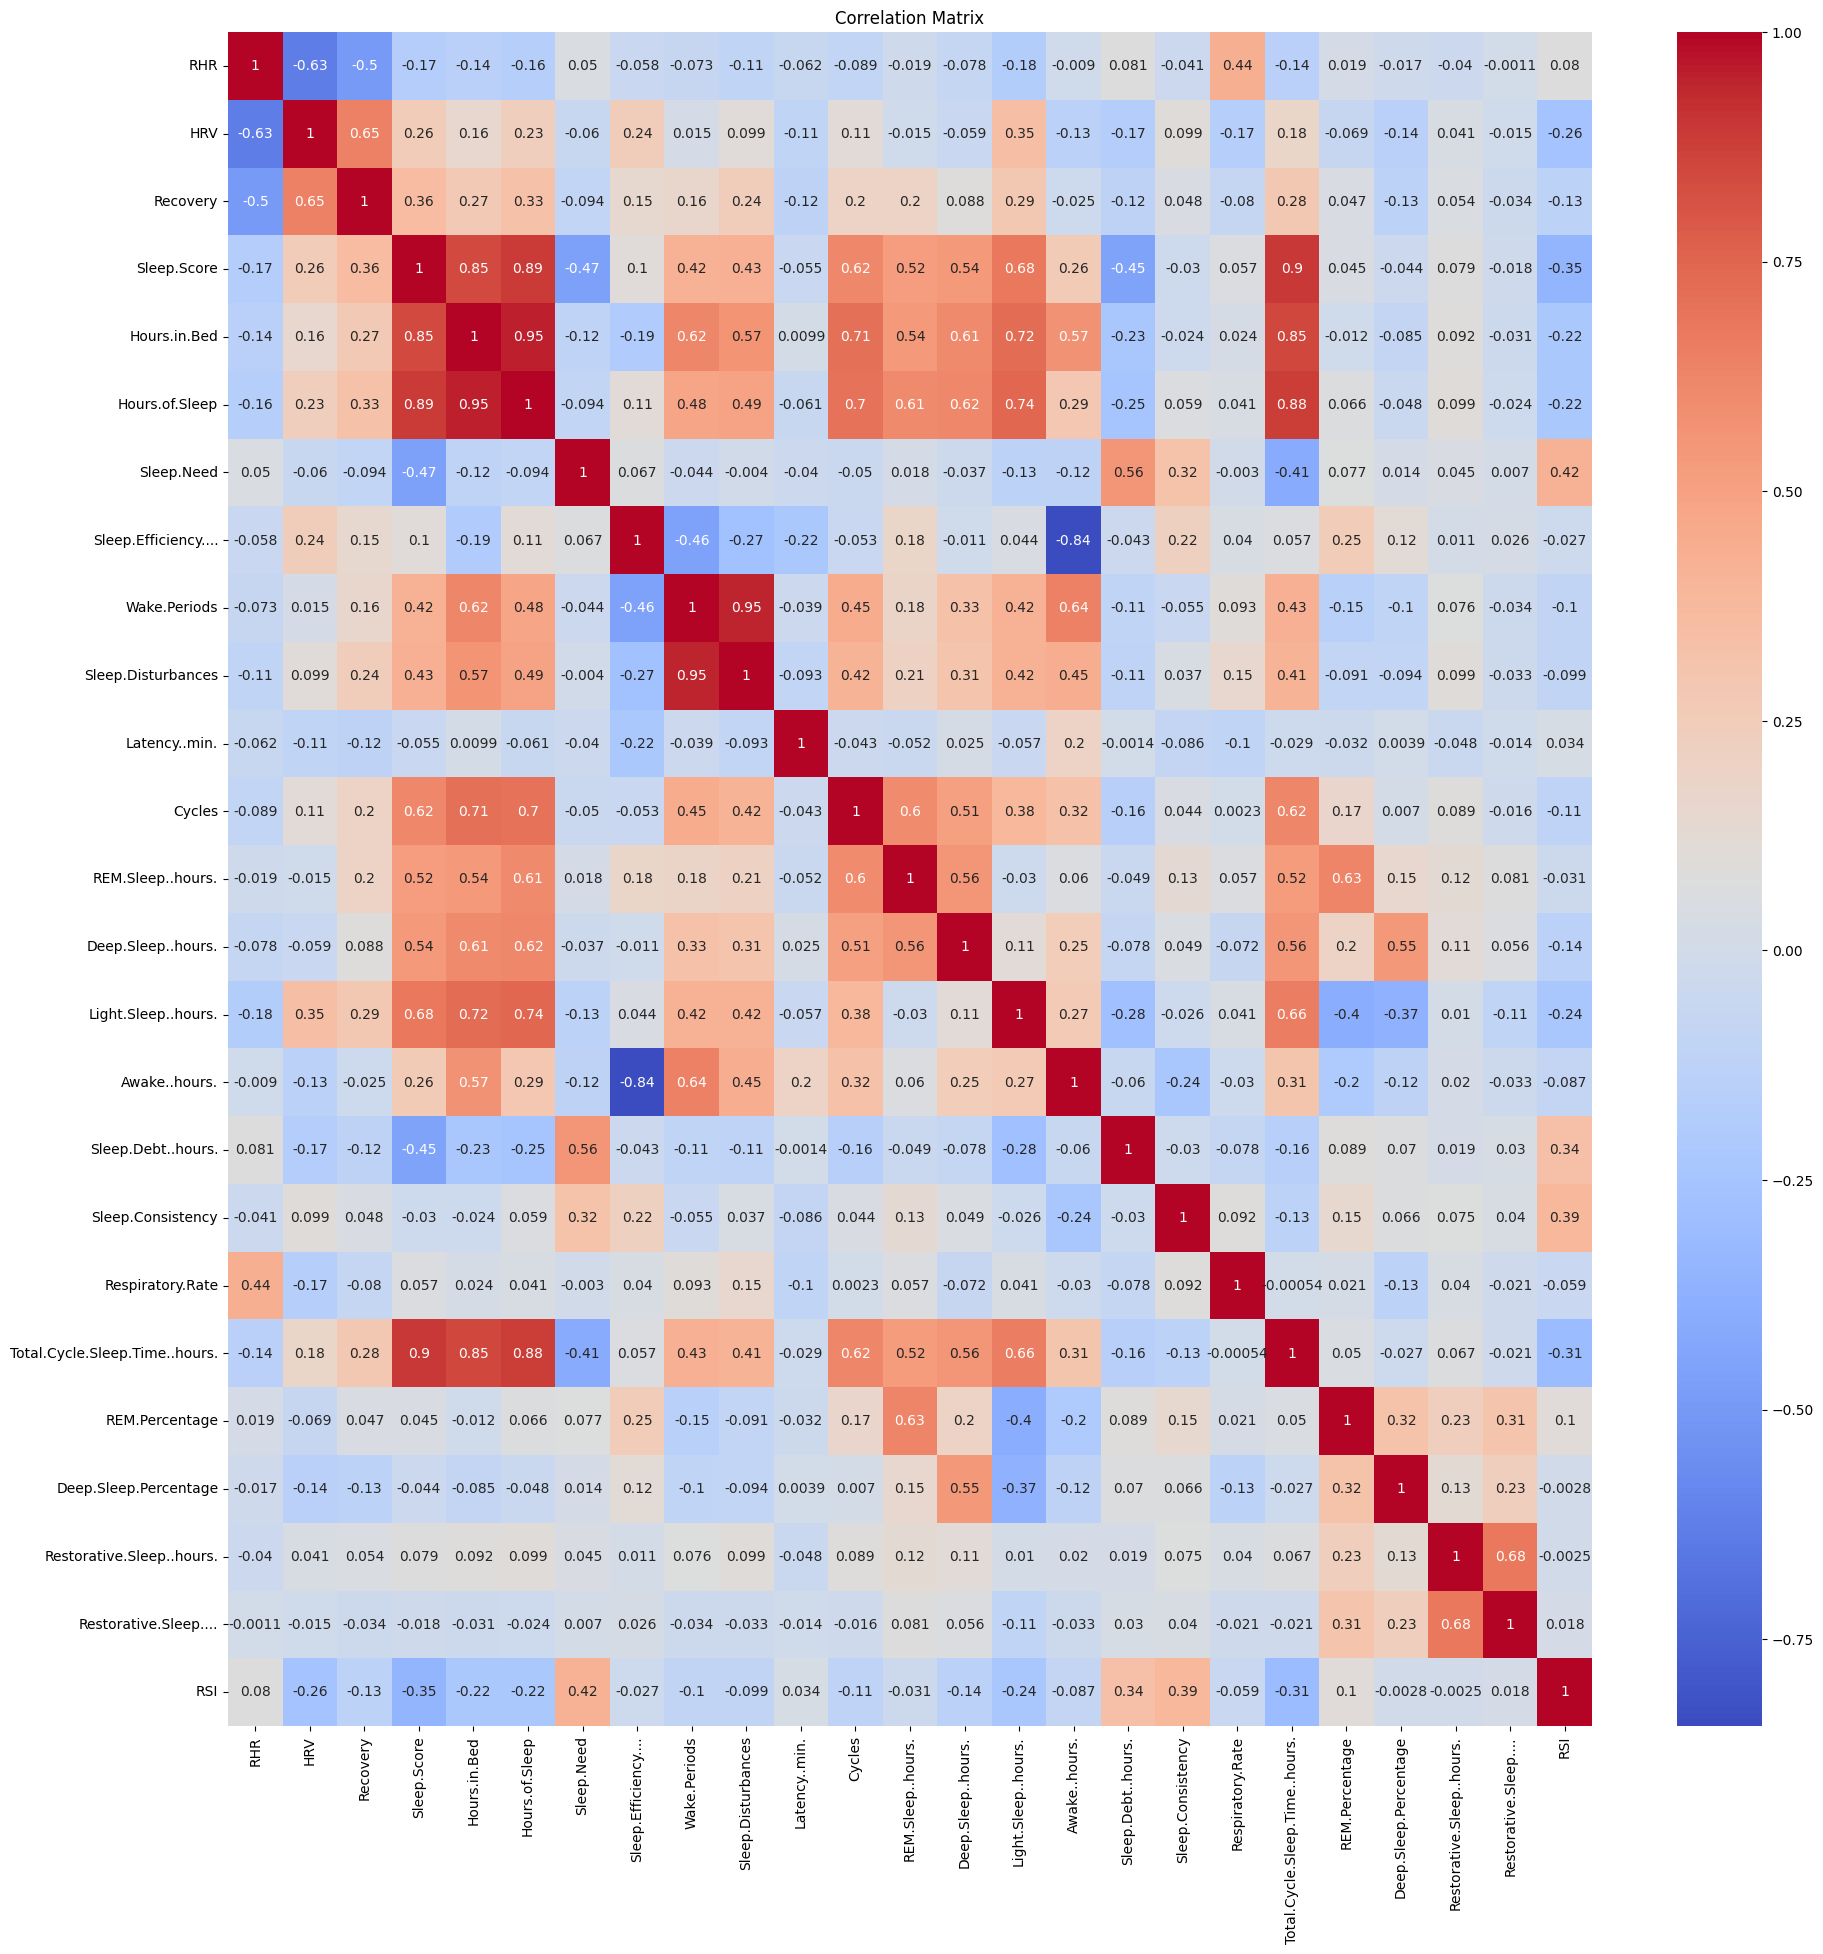

In [48]:
import seaborn as sns

fig = plt.figure(figsize=(22,22))
corr_matrix = df_imputed.corr()
sns.heatmap(corr_matrix, annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()



In [49]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_imputed), columns=df_imputed.columns)

print(df_scaled.shape)

print(df_scaled.head())

df_scaled.to_csv('Athelete_scaled.csv', index=False)


(3111, 25)
        RHR       HRV  Recovery  Sleep.Score  Hours.in.Bed  Hours.of.Sleep  \
0  0.231481  0.495977  0.744592     0.780889      0.438209        0.562939   
1  0.111111  0.609195  0.581633     0.455556      0.330224        0.417391   
2  0.231481  0.495977  0.744592     0.780889      0.438209        0.562939   
3  0.231481  0.495977  0.744592     0.780889      0.438209        0.562939   
4  0.172840  0.614943  0.612245     0.500000      0.323383        0.412174   

   Sleep.Need  Sleep.Efficiency....  Wake.Periods  Sleep.Disturbances  ...  \
0    0.725177              0.880595      0.266852            0.328913  ...   
1    0.890810              0.857143      0.092593            0.130435  ...   
2    0.725177              0.880595      0.266852            0.328913  ...   
3    0.725177              0.880595      0.266852            0.328913  ...   
4    0.811647              0.869048      0.111111            0.152174  ...   

   Awake..hours.  Sleep.Debt..hours.  Sleep.Consist

In [59]:
threshold = 0.1
correlation_with_target = corr_matrix['RSI'].sort_values(ascending=False)
selected_features = correlation_with_target[abs(correlation_with_target)>=threshold].index
df_reduced = df_scaled[selected_features]
print(df_reduced.shape)
print(df_reduced.head())

(3111, 15)
        RSI  Sleep.Need  Sleep.Consistency  Sleep.Debt..hours.  \
0  0.395106    0.725177           0.739239            0.286063   
1  0.276596    0.890810           0.564348            0.922414   
2  0.395106    0.725177           0.739239            0.286063   
3  0.395106    0.725177           0.739239            0.286063   
4  0.316170    0.811647           0.391304            0.543103   

   REM.Percentage  Wake.Periods    Cycles  Recovery  Deep.Sleep..hours.  \
0        0.511190      0.266852  0.441538  0.744592            0.454295   
1        0.488848      0.092593  0.230769  0.581633            0.465574   
2        0.511190      0.266852  0.441538  0.744592            0.454295   
3        0.511190      0.266852  0.441538  0.744592            0.454295   
4        0.466543      0.111111  0.230769  0.612245            0.177049   

   Hours.in.Bed  Hours.of.Sleep  Light.Sleep..hours.       HRV  \
0      0.438209        0.562939             0.370427  0.495977   
1      0.

In [60]:
df_reduced.to_csv('Athelete_reduced.csv',index=False)